In [28]:
import os, sys

import numpy as np
import awkward as ak
import hist
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep

parent_dir = os.path.dirname(os.path.abspath(""))
sys.path.append(parent_dir)

import plot_utils

In [15]:
hep.style.use(hep.style.CMS)
mpl.rcParams["figure.facecolor"] = "white"

In [2]:
tag = "full_analysis_Feb2026"
years_to_load = ["2016", "2017", "2018"]
plots = {}
for year in years_to_load:
    plots = plots | plot_utils.loader(tag=f"{tag}_{year}_SRs", era=year)

In [3]:
run2_plots = plot_utils.merge_runs(plots, "Run2", data=False)
plots = plots | run2_plots

In [8]:
plots_tt = plots["TT_powheg_Run2"]

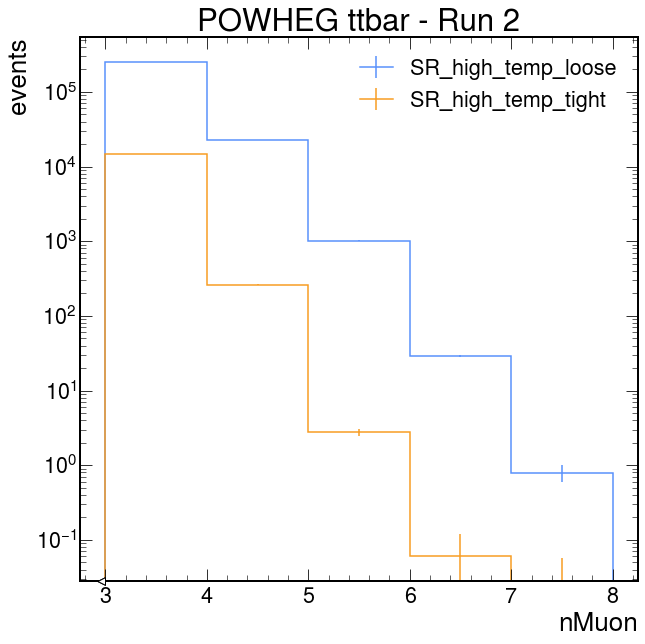

In [27]:
plots_tt["SR_high_temp_loose"].plot(label="SR_high_temp_loose")
plots_tt["SR_high_temp_tight"].plot(label="SR_high_temp_tight")
plt.yscale("log")
plt.ylabel("events")
plt.legend()
plt.title("POWHEG ttbar - Run 2")
plt.show()

In [42]:
def divide_hists(num: hist.Hist, den: hist.Hist, *, flow: bool = False) -> hist.Hist:
    """Return num / den with standard independent-error propagation."""

    a = num.values(flow=flow)
    b = den.values(flow=flow)
    va = num.variances(flow=flow)
    vb = den.variances(flow=flow)

    if va is None or vb is None:
        raise ValueError("Both histograms must provide variances")

    ratio = np.full(a.shape, np.nan, dtype=float)
    variance = np.full(a.shape, np.nan, dtype=float)

    valid = b != 0
    ratio[valid] = a[valid] / b[valid]
    variance[valid] = (
        va[valid] / b[valid] ** 2 + a[valid] ** 2 * vb[valid] / b[valid] ** 4
    )

    out = hist.Hist(*num.axes, storage=hist.storage.Weight())
    out[...] = np.stack((ratio, variance), axis=-1)
    return out

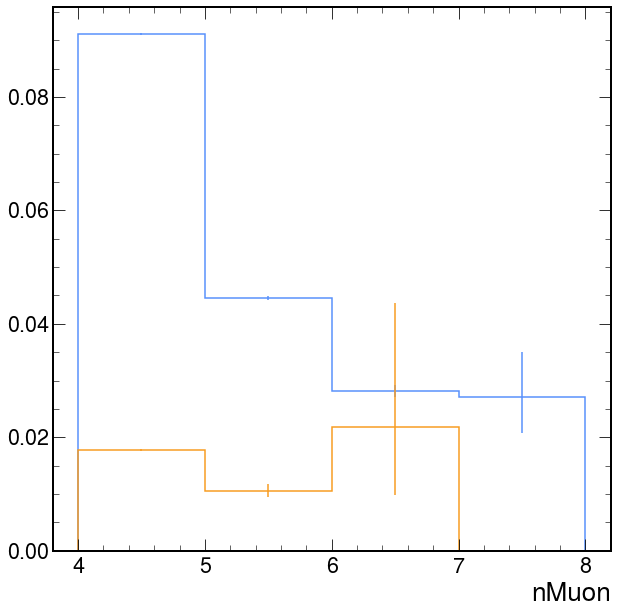

In [46]:
divide_hists(
    plots_tt["SR_high_temp_loose"][1:], plots_tt["SR_high_temp_loose"][:4]
).plot()
divide_hists(
    plots_tt["SR_high_temp_tight"][1:], plots_tt["SR_high_temp_tight"][:4]
).plot()
plt.show()

In [25]:
plots_tt['SR_high_temp_loose']. / plots_tt['SR_high_temp_loose']

AttributeError: 'boost_histogram._core.hist.any_weight' object has no attribute '__itruediv__'

In [40]:
plots_tt["SR_high_temp_loose"][:4]

Hist(Regular(4, 3, 7, name='nMuon'), storage=Weight()) # Sum: WeightedSum(value=275671, variance=11360.4) (WeightedSum(value=286487, variance=11858.6) with flow)

In [52]:
plots_tt["SR_high_temp_tight"][3].value * 0.03

0.0018190784200530893